In [51]:
library("ape")
library("phytools")
library("scatterplot3d")

In [6]:
tree <- ape::rtree(n = 100)

In [7]:
tree$tip.label

[1] "t23"  "t61"  "t58"  "t19"  "t87"  "t73"  "t63"  "t55"  "t41"  "t13" 
 [11] "t6"   "t47"  "t90"  "t45"  "t86"  "t22"  "t36"  "t40"  "t64"  "t91" 
 [21] "t10"  "t17"  "t39"  "t7"   "t65"  "t3"   "t85"  "t12"  "t60"  "t72" 
 [31] "t48"  "t69"  "t51"  "t100" "t83"  "t59"  "t52"  "t31"  "t37"  "t2"  
 [41] "t99"  "t82"  "t44"  "t92"  "t76"  "t97"  "t29"  "t78"  "t71"  "t67" 
 [51] "t9"   "t32"  "t46"  "t57"  "t5"   "t16"  "t70"  "t43"  "t1"   "t18" 
 [61] "t26"  "t35"  "t15"  "t75"  "t20"  "t96"  "t81"  "t54"  "t34"  "t98" 
 [71] "t93"  "t77"  "t74"  "t66"  "t84"  "t38"  "t88"  "t94"  "t50"  "t27" 
 [81] "t56"  "t4"   "t8"   "t42"  "t80"  "t89"  "t33"  "t62"  "t24"  "t49" 
 [91] "t79"  "t14"  "t95"  "t30"  "t21"  "t68"  "t28"  "t53"  "t25"  "t11"

In [35]:
x <- c(runif(n = 20), runif(min = 5, max = 10, n = 35), runif(min = 20, max = 25, n = 30), runif(n = 15))
y <- x * rnorm(n = 100, mean = 2.5, sd = 1)
z <- x * rnorm(n = 100, mean = 0.5, sd =.751)
traits <- cbind(x, y, z)
rownames(traits) <- tree$tip.label

In [52]:
# https://raw.githubusercontent.com/liamrevell/phytools/refs/heads/master/R/phylomorphospace3d.R

## phylomorphospace3d: projection of a tree into three dimensional morphospace
## written by Liam J. Revell 2012, 2013, 2014, 2016, 2018

phylomorphospace3d <- function(tree,X,A=NULL,label=TRUE,control=list(),method=c("dynamic","static"),...){
	method<-method[1]
	if(!inherits(tree,"phylo")) stop("tree should be an object of class \"phylo\".")
	# control list
	con=list(spin=TRUE,axes=TRUE,box=TRUE,simple.axes=FALSE,lwd=1,ftype="reg",
		col.edge=rep("black",nrow(tree$edge)))
	con[(namc<-names(control))]<-control
	if(con$simple.axes) con$box<-con$axes<-FALSE
	con$ftype<-which(c("off","reg","b","i","bi")==con$ftype)-1
	if(is.null(A)) A<-apply(X,2,function(x,tree) fastAnc(tree,x),tree=tree)
	else A<-A[as.character(1:tree$Nnode+length(tree$tip)),]
	x<-y<-z<-matrix(NA,nrow(tree$edge),2)
	X<-X[tree$tip.label,]
	for(i in 1:length(tree$tip)){
		x[tree$edge[,2]==i,2]<-X[i,1]
		y[tree$edge[,2]==i,2]<-X[i,2]
		z[tree$edge[,2]==i,2]<-X[i,3]
	}
	for(i in length(tree$tip)+1:tree$Nnode){
		x[tree$edge[,1]==i,1]<-x[tree$edge[,2]==i,2]<-A[as.character(i),1]
		y[tree$edge[,1]==i,1]<-y[tree$edge[,2]==i,2]<-A[as.character(i),2]
		z[tree$edge[,1]==i,1]<-z[tree$edge[,2]==i,2]<-A[as.character(i),3]
	}
	if(is.null(colnames(X))) colnames(X)<-c("x","y","z")
	if(method=="dynamic"){
		chk<-.check.pkg("rgl")
		if(!chk){
			cat("  method = \"dynamic\" requires the package \"rgl\"\n  Defaulting to method = \"static\"\n\n")
			method<-"static"
			lines3d<-play3d<-plot3d<-segments3d<-spheres3d<-spin3d<-text3d<-function(...) NULL
		}
	}
	if(method=="dynamic"){
		params<-get("r3dDefaults")
		plot3d(rbind(X,A),xlab=colnames(X)[1],ylab=colnames(X)[2],zlab=colnames(X)[3],
			axes=con$axes,box=con$box,params=params)
		spheres3d(X,radius=0.02*mean(apply(X,2,max)-apply(X,2,min)))
		for(i in 1:nrow(tree$edge)) segments3d(x[i,],y[i,],z[i,],lwd=con$lwd,
			col=con$col.edge[i])
		ms<-colMeans(X)
		rs<-apply(rbind(X,A),2,range)
		if(con$simple.axes){
			lines3d(x=rs[,1],y=c(rs[1,2],rs[1,2]),z=c(rs[1,3],rs[1,3]))
			lines3d(x=c(rs[1,1],rs[1,1]),y=rs[,2],z=c(rs[1,3],rs[1,3]))
			lines3d(x=c(rs[1,1],rs[1,1]),y=c(rs[1,2],rs[1,2]),z=rs[,3])
		}
		rs<-rs[2,]-rs[1,]
		for(i in 1:length(tree$tip)){
			adj<-0.03*rs*(2*(X[i,]>ms)-1)
			if(con$ftype) text3d(X[i,]+adj,texts=tree$tip.label[i],font=con$ftype)
		}
		if(con$spin){
			xx<-spin3d(axis=c(0,0,1),rpm=10)
			play3d(xx,duration=5)
			invisible(xx)
		}
		else invisible(NULL)
	} else if(method=="static"){
		if(hasArg(angle)) angle<-list(...)$angle
		else angle<-30
		if(hasArg(xlim)) xlim<-list(...)$xlim
		else xlim<-NULL
		if(hasArg(ylim)) ylim<-list(...)$ylim
		else ylim<-NULL
		if(hasArg(zlim)) zlim<-list(...)$zlim
		else zlim=NULL
		xx <-scatterplot3d(X,pch=19,angle=angle,cex.symbols=1.3,xlim=xlim,ylim=ylim,zlim=zlim, ...)
		aa<-xx$xyz.convert(A)
		points(aa$x,aa$y,pch=19,cex=0.8)
		for(i in 1:nrow(tree$edge)){
			aa<-xx$xyz.convert(x[i,],y[i,],z[i,])
			lines(aa$x,aa$y,lwd=2,col=con$col.edge[i])
		}
		for(i in 1:length(tree$tip.label)){
			aa<-xx$xyz.convert(x[which(tree$edge[,2]==i),2],y[which(tree$edge[,2]==i),2],
				z[which(tree$edge[,2]==i),2])
			if(con$ftype) text(tree$tip.label[i],x=aa$x,y=aa$y,pos=2,font=con$ftype)
		}
		invisible(xx)
	}
}

## check for a package (modified from 'geiger')
## primarily used for rgl
## written by Liam J. Revell 2014, 2022
.check.pkg<-function(pkg){
	if(pkg%in%rownames(installed.packages())){
		require(pkg,character.only=TRUE)
		return(TRUE)
	} else return(FALSE)
}


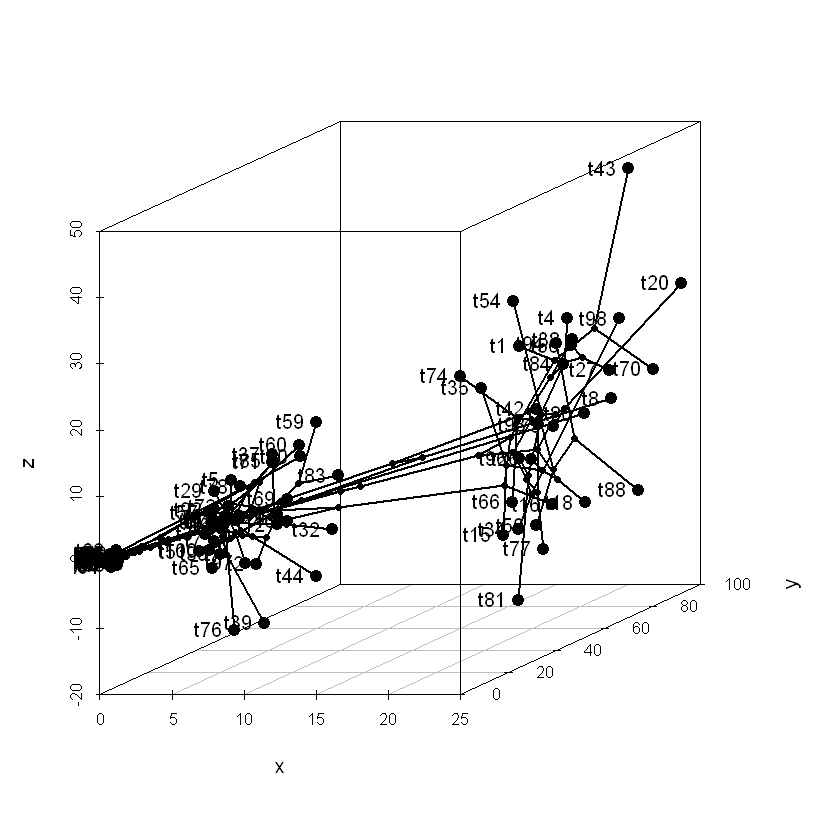

In [49]:
phytools::phylomorphospace3d(tree = tree, X = traits, label = FALSE, method = "static")#, xlab = "T1", ylab = "T2", color = "red")

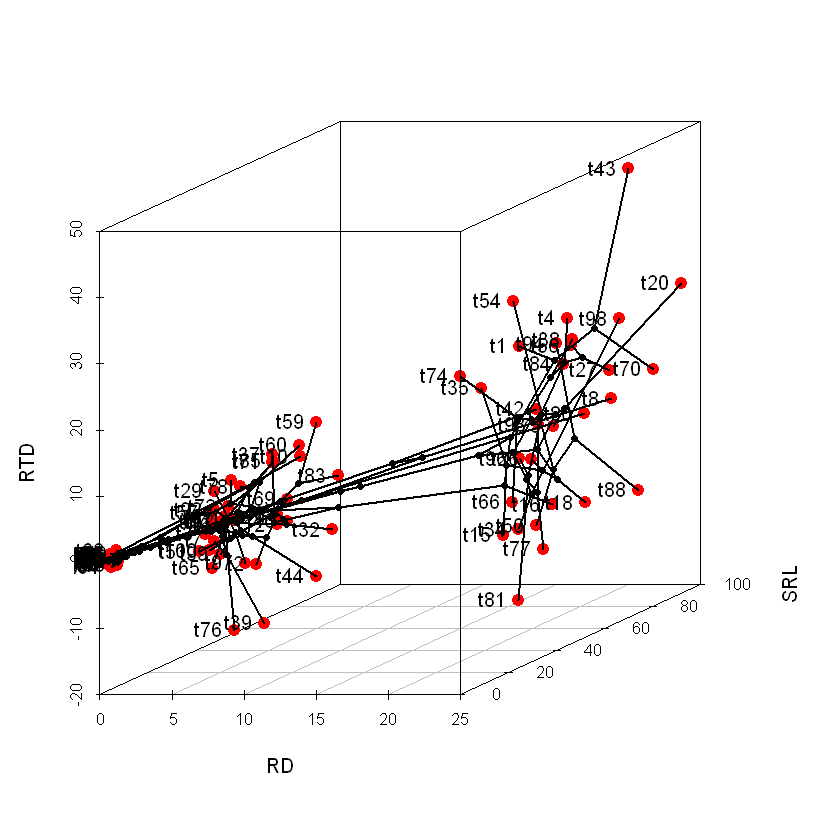

In [66]:
phylomorphospace3d(tree = tree, X = traits, label = FALSE, method = "static", xlab = "RD", ylab = "SRL",  zlab = "RTD", color = "red")